# Demo: Signal ↔ Action Trace + Plot BUY/SELL

Notebook này minh họa nhanh 2 điểm:
1. Cách gắn và truy vết `signal_id` / `action_ids`.
2. Cách `plot_signal()` vẽ cả điểm BUY/SELL và tự extend tới điểm SELL, sau đó cộng thêm `extend_bars`.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

from vnstock_forecast.builtin.forecast.signal import Signal, SignalDirection, TradePlan
from vnstock_forecast.builtin.forecast.visualization.snapshot import SignalSnapshot
from vnstock_forecast.builtin.forecast.visualization.plotter import plot_signal

In [2]:
# --- Tạo dữ liệu OHLCV giả lập ---
np.random.seed(42)
idx = pd.date_range("2025-01-01", periods=80, freq="D")
base = 100 + np.cumsum(np.random.normal(0.2, 1.2, len(idx)))
close = pd.Series(base, index=idx).round(2)
open_ = (close.shift(1).fillna(close.iloc[0]) + np.random.normal(0, 0.5, len(idx))).round(2)
high = pd.concat([open_, close], axis=1).max(axis=1) + np.abs(np.random.normal(0.8, 0.3, len(idx)))
low = pd.concat([open_, close], axis=1).min(axis=1) - np.abs(np.random.normal(0.8, 0.3, len(idx)))
vol = np.random.randint(200_000, 800_000, len(idx))

ohlcv = pd.DataFrame({
    "Open": open_.round(2),
    "High": high.round(2),
    "Low": low.round(2),
    "Close": close.round(2),
    "Volume": vol,
}, index=idx)

entry_time = idx[25]
exit_time = idx[56]
entry_price = float(ohlcv.loc[entry_time, "Close"])
exit_price = float(ohlcv.loc[exit_time, "Close"])

entry_price, exit_price

(100.43, 99.07)

In [3]:
# --- Tạo Signal BUY và gắn trace sang actions ---
buy_signal = Signal(
    technique="demo_sma",
    symbol="DEMO",
    direction=SignalDirection.BUY,
    timestamp=entry_time.to_pydatetime(),
    trade_plan=TradePlan(
        entry=entry_price,
        stop_loss=round(entry_price * 0.93, 2),
        take_profit=round(entry_price * 1.12, 2),
        max_holding_days=20,
    ),
    confidence=0.72,
    reason="SMA short cắt lên SMA long",
)

# Giả lập 2 actions liên quan signal này (1 BUY + 1 SELL)
buy_action_id = "act_buy_demo_01"
sell_action_id = "act_sell_demo_01"
buy_signal.attach_action(buy_action_id)
buy_signal.attach_action(sell_action_id)

# Metadata phục vụ plot và trace
buy_signal.metadata.update({
    "entry_time": entry_time.to_pydatetime(),
    "entry_price": entry_price,
    "exit_time": exit_time.to_pydatetime(),
    "exit_price": exit_price,
})

buy_signal.snapshot = SignalSnapshot(
    ohlcv=ohlcv.iloc[:40],  # cố ý cắt ngắn để thấy auto-extend
    symbol="DEMO",
    resolution="D",
    signal_time=buy_signal.timestamp,
    entry=buy_signal.trade_plan.entry,
    entry_time=entry_time.to_pydatetime(),
    stop_loss=buy_signal.trade_plan.stop_loss,
    take_profit=buy_signal.trade_plan.take_profit,
    exit_time=exit_time.to_pydatetime(),
    exit_price=exit_price,
)

print("signal_id:", buy_signal.signal_id)
print("action_ids:", buy_signal.action_ids)
print("entry/exit:", buy_signal.metadata["entry_time"], "->", buy_signal.metadata["exit_time"])

signal_id: eb2d7b9a4511
action_ids: ['act_buy_demo_01', 'act_sell_demo_01']
entry/exit: 2025-01-26 00:00:00 -> 2025-02-26 00:00:00


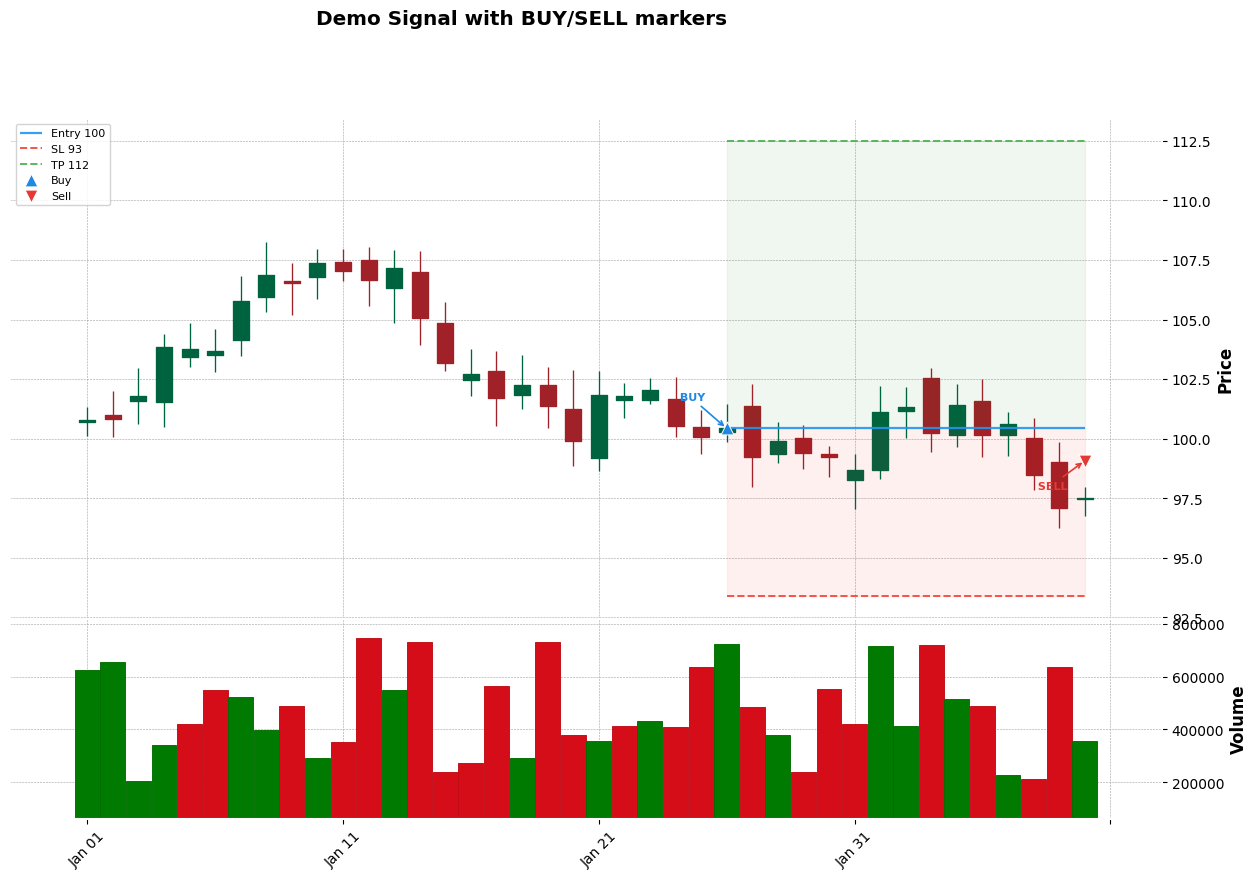

In [4]:
# --- Plot BUY/SELL ---
# plot_signal sẽ tự extend tới exit_time trước, rồi cộng thêm extend_bars
fig = plot_signal(
    buy_signal,
    extend_bars=12,
    title="Demo Signal with BUY/SELL markers",
    show=True,
)

In [5]:
# --- Ví dụ truy vết 2 chiều (in-memory) ---
signal_to_actions = {buy_signal.signal_id: buy_signal.action_ids}
action_to_signal = {aid: buy_signal.signal_id for aid in buy_signal.action_ids}

print("signal_to_actions:", signal_to_actions)
print("action_to_signal:", action_to_signal)

signal_to_actions: {'eb2d7b9a4511': ['act_buy_demo_01', 'act_sell_demo_01']}
action_to_signal: {'act_buy_demo_01': 'eb2d7b9a4511', 'act_sell_demo_01': 'eb2d7b9a4511'}
